In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

Import database/data

In [233]:
conn = sqlite3.connect('customer_churn_data.db')

In [234]:
conn = sqlite3.connect('customer_churn_data.db')

sql_query = """
     SELECT name FROM sqlite_master where type = 'table'
"""

tables = pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_table_{table_name}")
    #print(f"df_{table_name} created -> {len(df)} rows")

conn.close()


Created dataframe: df_table_customers
Created dataframe: df_table_db_customer
Created dataframe: df_table_db_subscription
Created dataframe: df_table_db_support


In [235]:
#print table names and column names
conn = sqlite3.connect('customer_churn_data.db')

for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    #Pragma - > get column information
    column_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(column_query,conn)
    print("columns")
    print(columns['name'].tolist())

# close connection
conn.close()   


Table Name:customers
columns
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_customer
columns
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
columns
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
columns
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [214]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None


In [144]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [145]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [146]:
#Rename column - name
#drop columns - interests and pincode
#change data type - dob
#data standardizarion - gender
#fix missing value - country 

In [147]:
# Rename column - name
#df_db_customer.rename(columns = {'name': 'customer_name'}, inplace = True)
df_db_customer= df_db_customer.rename(columns = {'name': 'customer_name'})
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [148]:
#drop columns - interests and pincode
# index basis
#df_db_customer.drop(df_db_customer.columns[-2:],axis = 1)
#or
df_db_customer.drop(df_db_customer.columns[6:],axis = 1)
#or 
#df_db_customer.drop(columns = ['interests' , 'pincode'], inplace = True)

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [149]:
#change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer['dob']

0    1982-04-12
1    1995-11-23
2    1978-02-15
3    2001-08-30
4    1990-05-05
5    1988-12-10
6    1976-09-21
7    1999-03-14
8    1985-07-07
9    1993-10-29
10   1997-01-22
11   1981-06-18
12   2004-12-01
13   1992-04-25
14   1979-11-11
15   1986-02-28
16   1994-08-19
17   2000-09-02
18   1983-12-30
19   1991-05-14
20   1977-10-06
Name: dob, dtype: datetime64[ns]

In [150]:
df_db_customer['gender'].unique()


array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [151]:
# data standardizarion - gender

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})
df_db_customer['gender']

0       Male
1       Male
2     Female
3       Male
4     Female
5     Female
6     Female
7       Male
8     Female
9       Male
10      Male
11    Female
12    Female
13    Female
14      Male
15    Female
16    Female
17    Female
18      Male
19      Male
20    Female
Name: gender, dtype: object

In [152]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [153]:
# fix missing value - country 
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07,None,None
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01,None,None


In [154]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [155]:
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()
state_country_mapping 

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [156]:
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))
df_db_customer['country'] 

0     India
1     India
2     India
3     India
4     India
5     India
6     India
7     India
8     Nepal
9     Nepal
10    India
11    India
12    India
13    India
14    India
15    India
16    India
17    India
18    India
19    India
20    India
Name: country, dtype: object

In [157]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [158]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [159]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [160]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [161]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [162]:
df_db_support.drop(columns = ['col_1','comment'],inplace = True)

In [163]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


Feature Engineering and Data Analysis

In [164]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34


In [165]:
# create a new colusing existing col - churn flag
df_db_subscription['churn_flag'] = np.where( df_db_subscription['cancellation_date'].notna(),1,0)

In [166]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [167]:
# First fix support table duplicates then merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid',how = 'left')
    .merge(df_db_support, on = 'customerid',how = 'left'))

In [168]:
df_db_subscription.shape

(21, 12)

In [169]:
# remove duplicates records from support table - first aggregate 
df_support_clean = df_db_support.groupby('customerid', as_index=False).agg(
    complaint_count=('customerid', 'count'),
    avg_csat=('csat_score', 'mean'),
    total_escalations=('escalations', 'sum')
)

# merge
df = df_db_subscription.merge(df_db_customer, on='customerid', how='left') \
                      .merge(df_support_clean, on='customerid', how='left')

df['complaint_count'] = df['complaint_count'].fillna(0)

df.shape

(21, 22)

In [170]:
df.shape

(21, 22)

In [171]:
df_db_subscription['customerid'].nunique()

21

In [172]:
df_db_support['customerid'].nunique()

7

In [173]:
df_db_support['customerid'].size

9

In [174]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [175]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [176]:
df_db_support['complaint_count']

0    2
1    2
2    1
3    1
4    1
5    1
6    1
7    2
8    2
Name: complaint_count, dtype: int64

In [177]:
df_db_support = df_db_support.sort_values('complaint_count').drop_duplicates('customerid', keep = 'last' )

In [178]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [179]:
df_db_support['customerid'].size

7

In [180]:
# merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid',how = 'left')
    .merge(df_db_support, on = 'customerid',how = 'left'))

In [181]:
df.shape

(21, 23)

In [182]:
df.to_csv('exported_churn_data.csv', index= False)

In [183]:
# Data Analysis


In [184]:
# Churn Rate

In [185]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count'],
      dtype='object')

In [186]:
churn_rate = df['churn_flag'].mean()*100
print("churn Rate = ", round(churn_rate,2),"%")

churn Rate =  28.57 %


In [187]:
#2. Retention Rate
retention_rate = 100-churn_rate
print("Retention Rate = ", round(retention_rate,2),"%")


Retention Rate =  71.43 %


In [188]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,interests,pincode,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,travel,None,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,None,None,2024-08-28,Y,10.0,2.0


In [189]:
# 3. Churn by Plan type
churn_by_plan =( df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [190]:
# 4 Churn by state
churn_by_state =( df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [191]:
# 4 Churn by subscription type

churn_by_subscription =( df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_subscription)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [192]:
# 5. ARPU - avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU=', round(arpu , 2))

ARPU= 18.85


In [193]:
# 6. Avg Customer Tenure
# count of days users has used our services: cancellation date else current date
Today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
  (df['cancellation_date'] - df['subscription_start_date']).dt.days,
  (Today - df['subscription_start_date']).dt.days
  )
avg_tenure = df['tenure_days'].mean()
print("avg_tenure(Days) = ", round(avg_tenure),0)

avg_tenure(Days) =  1547 0


In [194]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days'],
      dtype='object')

In [195]:
# 7.  Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk(Rs 'K') = ", revenue_at_risk)

Revenue at Risk(Rs 'K') =  73.94


In [196]:
# Esclation Rate
escalations_rate = (df['escalations']=='Y').mean()* 100
print("Escalations Rate =", round(escalations_rate,2),"%")

Escalations Rate = 19.05 %


In [197]:
#9. Avg Complaint per user
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Complaint per user= " , round(avg_complaints,2))

Avg Complaint per user=  0.43


In [198]:
# 1. escalations ko encode karo - comment hatao
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
churn_col = 'Churn'  # <-- yaha apna sahi naam likh do


In [199]:
# Correlation Escalations vs churn

#df['escalations'] = np.where(df['escalations'] == 'Y',1,0)#encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalations vs churn is = " , round(correlation,2))

Correlation between escalations vs churn is =  0.77


In [200]:
# 11 Churn risk - create a column using existing col
conditions = [
    (df['churn_score']<50),
    (df['churn_score']>= 50) & (df['churn_score'] <70),
    (df['churn_score'] > 70 )]
choices = ['low', 'med' , 'high']

df['churn_risk'] = np.select(conditions, choices, default= 'unkown')


        

In [201]:
df[['churn_risk', 'churn_score']].head()

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88


In [202]:
# Visulization Using Matplotlib

In [203]:
df_visual = df.copy()

In [204]:
df_visual.shape

(21, 25)

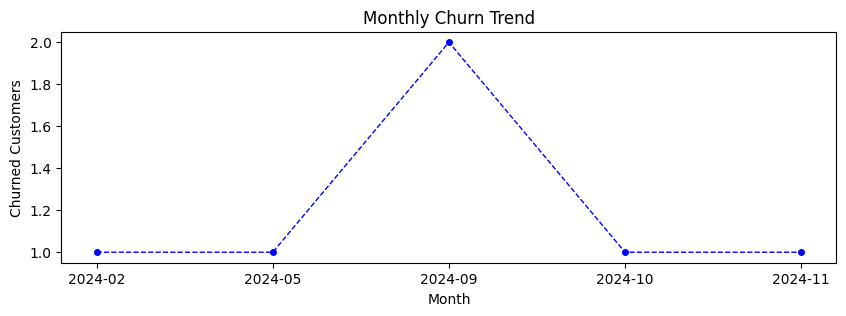

In [205]:
# Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(10,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values, marker='o',color = 'blue', linestyle='dashed',linewidth=1, markersize=4)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

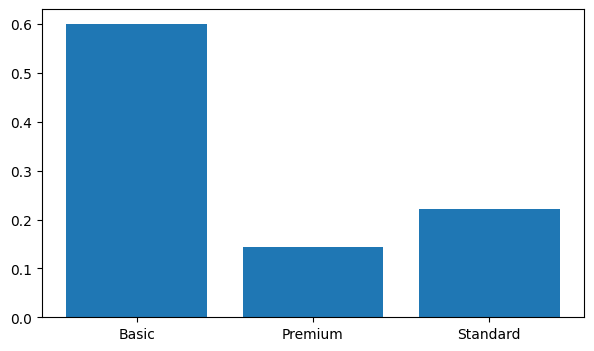

In [206]:
# Churn by Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize = (7,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.show()

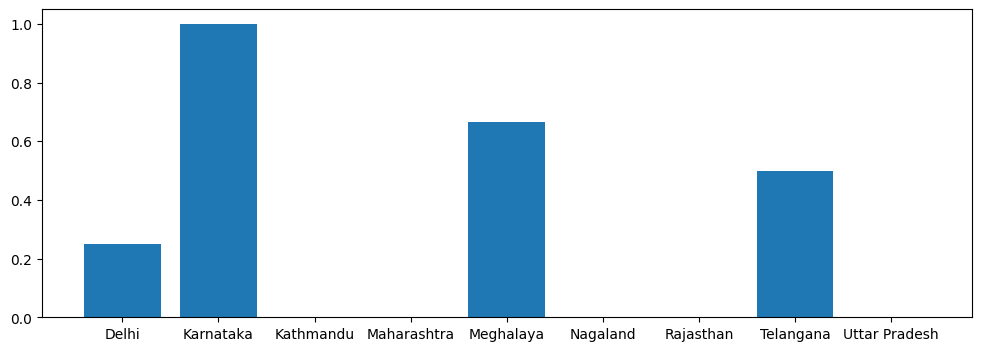

In [207]:
# Churn by State
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize = (12,4))
plt.bar(churn_plan.index, churn_plan.values)
plt.show()

In [208]:
# Visulaization using Seaborn

In [209]:
# Encoding -> convert str to numeric so that we can find corr between feature
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [210]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [215]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [216]:
import warnings
warnings.filterwarnings("ignore")

# INCORRECT METHOD OF ENCODING - AS NUMBER ARE NOT ASSIGHNED 

df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations']]

categorical_cols = ['plan_type','contract_type','churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

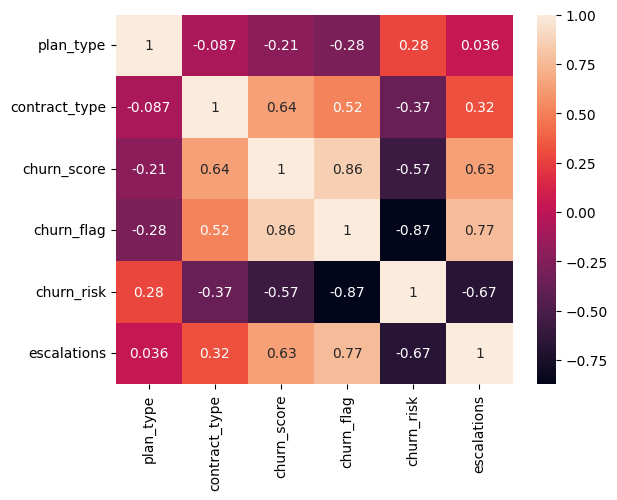

In [217]:
#Heatmap (Correletaion matrix)

sns.heatmap(df_encoded.corr(),annot = True)

In [218]:
df_visual[['plan_type', 'contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [219]:
import warnings
warnings.filterwarnings("ignore")

# CORRECT METHOD OF ENCODING - AS NUMBER ARE NOT ASSIGHNED 

df_encoded = df_visual[['plan_type', 'contract_type','churn_score','churn_flag',
                        'churn_risk']]

order_mappings = {
    'plan_type': ['Basic','Standard', 'Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low' , 'high']    
}
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

In [220]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk
0,1,1,12,0,0
1,2,1,91,1,1
2,0,0,34,0,0
3,2,1,8,0,0
4,1,0,88,1,1


<Axes: >

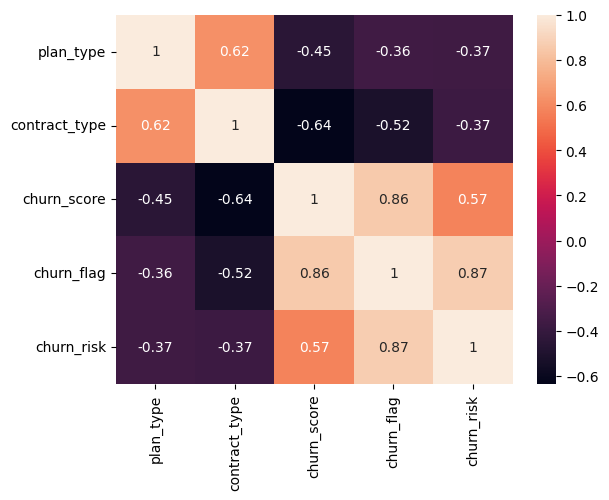

In [221]:
#Heatmap (Correletaion matrix)

sns.heatmap(df_encoded.corr(),annot = True)

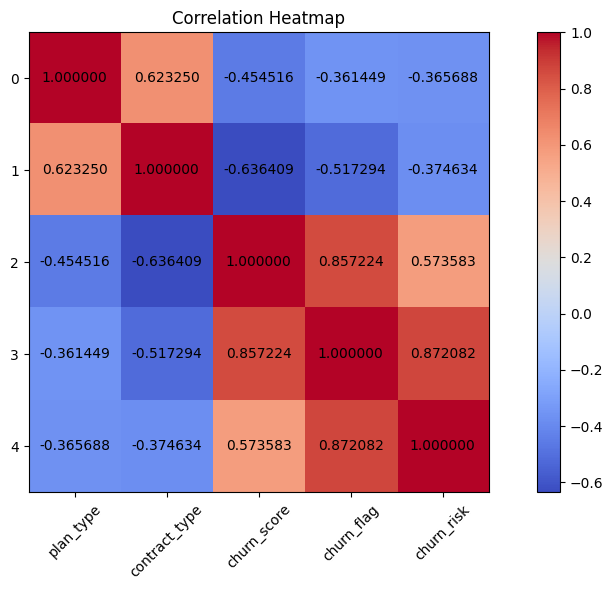

In [222]:
# Heatmap using Matplotlib - difficult to plot it 

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10,6)) # create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_xticklabels(corr_matrix.columns)

#Annotate values inside cells
for i in range(len(corr_matrix.columns)):
   for j in range(len(corr_matrix.columns)):
       ax.text(
           j,
           i,
           f"{corr_matrix.iloc[i,j]:2f}",
           ha = 'center',
           va = 'center'
       )
plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

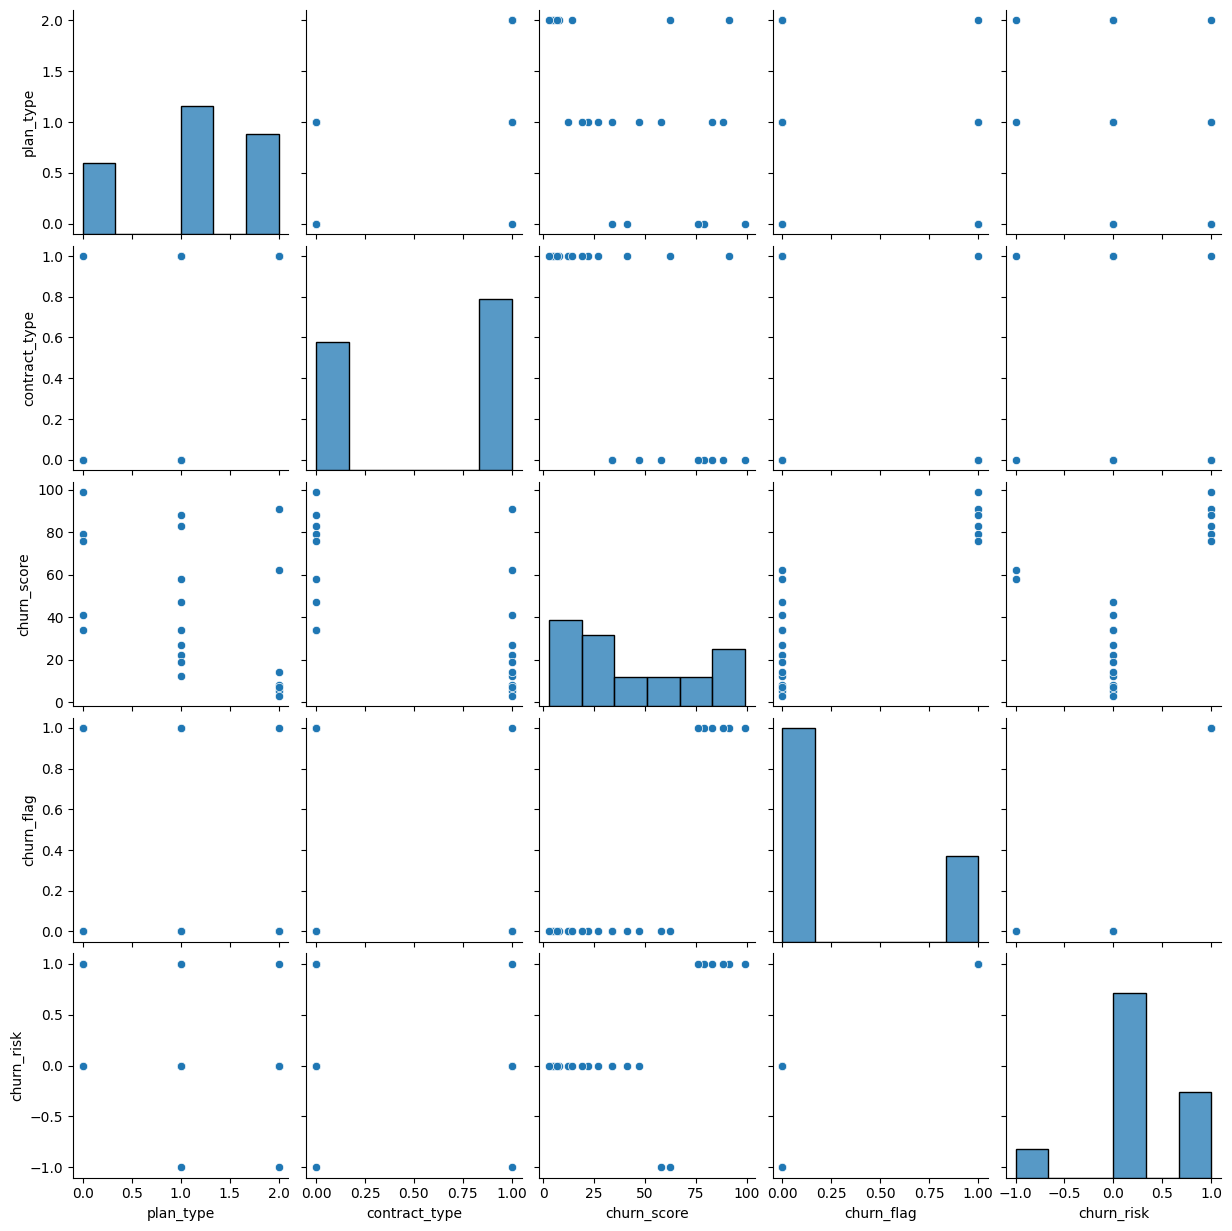

In [223]:
# Pairplot - relationship in a dataset
sns.pairplot(df_encoded)

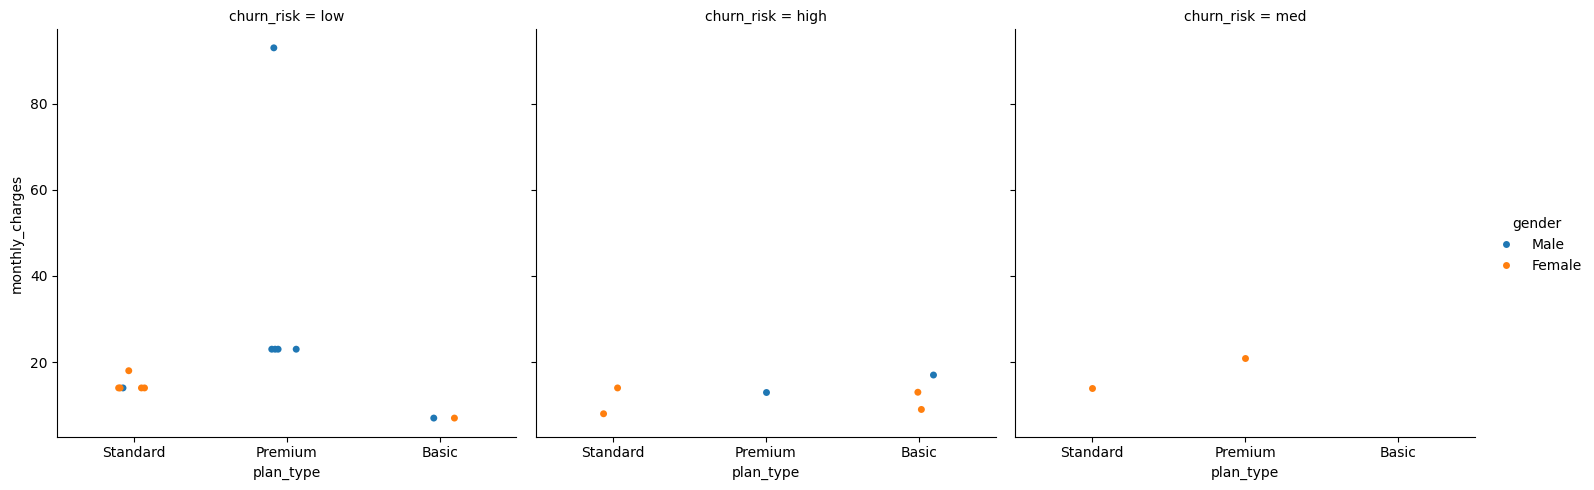

In [224]:
# catplt/Facegrid plot - multi-dim comparision

sns.catplot(data= df_visual,
            x= 'plan_type',
            y= 'monthly_charges',
            hue= 'gender',       
            col= 'churn_risk')

In [225]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'churn_risk'],
      dtype='object')

In [226]:
#Pivot Table

In [227]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index='plan_type',
    aggfunc = 'mean')

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [228]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index='plan_type',
    aggfunc = 'mean').reset_index

<bound method DataFrame.reset_index of            churn_flag
plan_type            
Basic        0.600000
Premium      0.142857
Standard     0.222222>

In [229]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode', 'complaint_date', 'escalations', 'csat_score',
       'complaint_count', 'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [230]:
pd.pivot_table(
    df_visual,
    values = ['monthly_charges','customerid','churn_flag'],
    index='plan_type',
    aggfunc = {'monthly_charges': 'sum',
               'customerid': 'nunique',
               'churn_flag': 'mean'
              }
               )

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [231]:
# Working with SQL in python(Pandas)


In [237]:
# create db in sql

conn = sqlite3.connect('test_database.sq;ite')

# table details
conn.execute("CREATE TABLE users(first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit

OperationalError: table users already exists

In [238]:
# insert data

cursor = conn.cursor()

cursor.execute(
    """
    INSERT INTO users VALUES
    ('Ali', 'India', 6000),
    ('Sam', 'Germany', 5000),
    ('Sam' , 'India', 4500)
    """
)
 # commit and save
conn.commit()

print("Data Inserted Successfully")
     

Data Inserted Successfully


In [239]:
# check inserted data in table
conn = sqlite3.connect('test_database.sq;ite')

query = """SELECT * FROM users"""
df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Ali,India,6000
1,Sam,Germany,5000
2,Sam,India,4500
3,Ali,India,6000
4,Sam,Germany,5000


In [240]:
# Aggregation
query = """
SELECT country, sum(budget) as total_budget FROM users
GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,15000
1,India,31500


In [241]:
# always close the conn with db once the task is over
conn.close()

In [242]:
df['escalations'].value_counts(dropna=False)

escalations
Y    5
N    4
Name: count, dtype: int64